In [ ]:
import pandas as pd
from google.colab import files
import io

# Upload file từ máy tính lên Colab
uploaded = files.upload()

# Lấy tên file vừa upload
file_name = list(uploaded.keys())[0]

# Đọc file CSV
dataset = pd.read_csv(io.BytesIO(uploaded[file_name]))

Saving processed_data_translated_en_split_clauses.csv to processed_data_translated_en_split_clauses.csv


In [ ]:
# Rename columns
dataset = dataset.rename(columns={'Clause': 'Feedback'})

display(dataset.head(10))

,review_id,Username,Address,Rating,Language,ID_clause,Feedback
0,1,Mashajo,An Bang Beach,5,ru,1.a,It's about 10-15 minutes away from the old cit...
1,1,Mashajo,An Bang Beach,5,ru,1.b,"The beach is wide, with soft sand and a long c..."
2,1,Mashajo,An Bang Beach,5,ru,1.c,It's quite calm and there's no feeling of a cr...
3,1,Mashajo,An Bang Beach,5,ru,1.d,There's a lot of cozy cafes and restaurants al...
4,1,Mashajo,An Bang Beach,5,ru,1.e,"By the way, many cafes have a bed and an umbre..."
5,2,cj h,An Bang Beach,5,en,2.a,Quiet and quaint. Very laid back vive
6,3,Hoàng Quỳnh,An Bang Beach,5,vi,3.a,"It's a wonderful calm beach with clear water, ..."
7,3,Hoàng Quỳnh,An Bang Beach,5,vi,3.b,but you're not seeing sunset.
8,4,Snus Hoi An,An Bang Beach,5,en,4.a,"While spending time in Hoi An, I was looking f..."
9,4,Snus Hoi An,An Bang Beach,5,en,4.b,"As an expat, it’s not always easy to find Scan..."


In [ ]:
# Extract metadata
review_id = list(dataset["review_id"])
clause_id = list(dataset["ID_clause"])
feedback = list(dataset["Feedback"])

In [ ]:
feedback[1]

'The beach is wide, with soft sand and a long coastline.'

# **1. Embedding**

In [ ]:
# Cài thư viện sentence-transformers trên Colab
!pip install -q sentence-transformers torch tqdm

In [ ]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer('thenlper/gte-small')
embeddings = embedding_model.encode(feedback, show_progress_bar=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/583 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/7242 [00:00<?, ?it/s]

In [ ]:
embeddings.shape

(231726, 384)

# **2. Reducing Dimensionality**

In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from umap import UMAP

umap_5d = UMAP(
    n_neighbors=30,
    n_components=5,
    min_dist=0.05,
    metric="cosine",
    random_state=42
)

embeddings_5d = umap_5d.fit_transform(embeddings)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


# **3. Cluster the Reduced Embedding**

In [ ]:
import numpy as np
from hdbscan import HDBSCAN

hdbscan_model = HDBSCAN(
    min_cluster_size=3500,     
    min_samples=50,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

clusters = hdbscan_model.fit_predict(embeddings_5d)

n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
n_outliers = np.sum(clusters == -1)

print("Number of clusters:", n_clusters)
print("Number of outliers:", n_outliers)

Number of clusters: 13
Number of outliers: 49322


# **4. Inspecting the Cluster**

In [ ]:
reduce_dimensions = UMAP(
        n_components=2,
        min_dist=0.0,
        metric="cosine",
        random_state=42
    ).fit_transform(embeddings)

print("Reduced embeddings shape:", reduce_dimensions.shape)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Reduced embeddings shape: (231726, 2)


# **Static Plot**

In [ ]:
df = pd.DataFrame(reduce_dimensions, columns=["x", "y"])
df["review_id"] = review_id
df["clause_id"] = clause_id
df["cluster"] = clusters

clusters_df = df[df["cluster"] != -1].copy()
outliers_df = df[df["cluster"] == -1].copy()

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

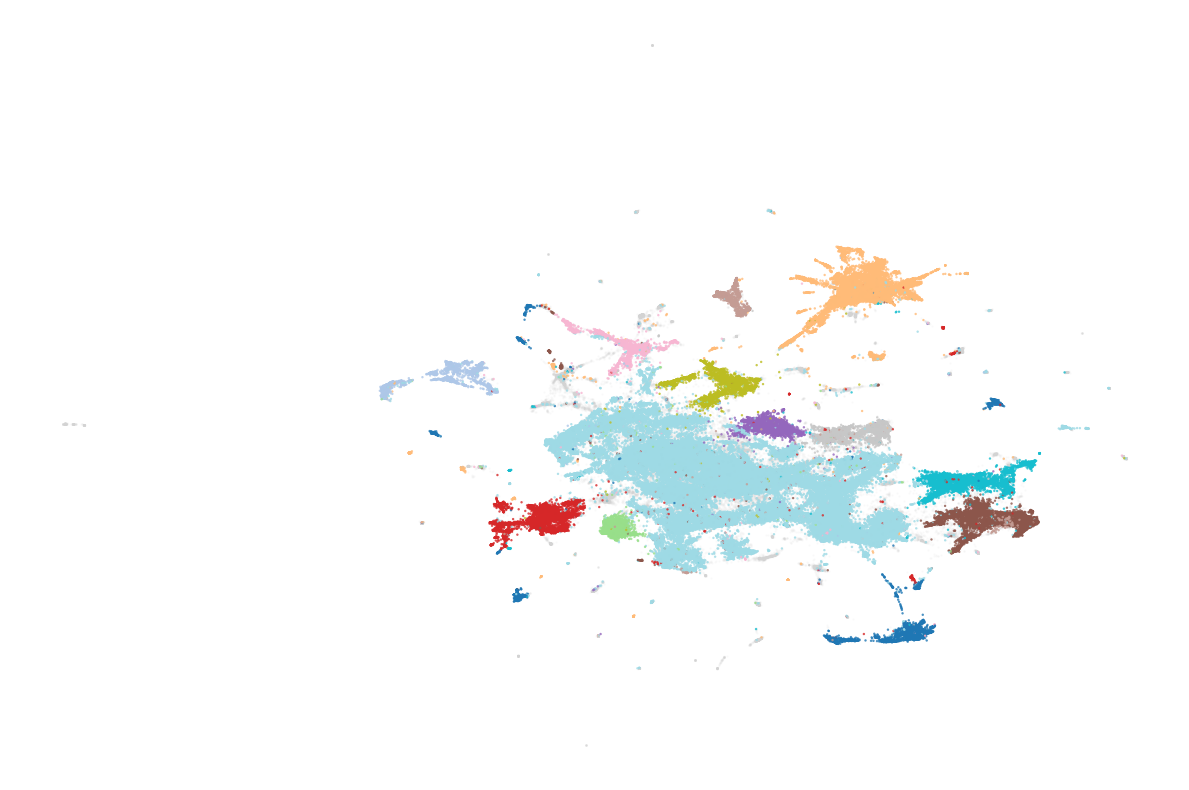

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

# vẽ outliers trước để nằm dưới nền
plt.scatter(
    outliers_df["x"],
    outliers_df["y"],
    c="lightgrey",
    s=2,
    alpha=0.12,
    linewidths=0
)

# vẽ cluster lên trên
plt.scatter(
    clusters_df["x"],
    clusters_df["y"],
    c=clusters_df["cluster"],
    cmap="tab20",
    s=3,
    alpha=0.8,
    linewidths=0
)

plt.axis("off")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/CCDNCTKHDL/matplotlib_fixed.png", dpi=300, bbox_inches="tight")
plt.show()

# **5. BERTopic**

In [ ]:
%%capture
pip install bertopic

In [ ]:
from bertopic import BERTopic

# Train our model with our previously defined models
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_5d,
    hdbscan_model=hdbscan_model,
    verbose=True
).fit(feedback, embeddings)

2026-05-11 01:33:51,623 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-11 01:43:43,936 - BERTopic - Dimensionality - Completed ✓
2026-05-11 01:43:43,945 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-11 01:44:20,239 - BERTopic - Cluster - Completed ✓
2026-05-11 01:44:20,281 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-11 01:44:23,496 - BERTopic - Representation - Completed ✓


In [ ]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,49322,-1_the_and_to_of,"[the, and, to, of, in, it, is, you, we, for]",[Did not get to spend much time there as the p...
1,0,88732,0_it_the_to_and,"[it, the, to, and, you, but, is, of, was, not]","[If you go early or late in the day, you can e..."
2,1,20125,1_vietnam_the_of_in,"[vietnam, the, of, in, vietnamese, hanoi, and,...",[The Central Post Office in Saigon / Ho Chi Mi...
3,2,10220,2_beach_the_and_water,"[beach, the, and, water, is, of, to, in, it, c...",[With too many tourists and rubbish on the bea...
4,3,10128,3_bridge_the_cable_dragon,"[bridge, the, cable, dragon, fire, and, car, t...","[but a bridge is just a bridge, A bridge is a ..."
5,4,9148,4_boat_the_bay_and,"[boat, the, bay, and, to, boats, on, we, of, h...","[The boat ride is beautiful., The ""Ha Long Bay..."
6,5,8899,5_park_the_rides_and,"[park, the, rides, and, to, water, of, is, for...","[but the water park is good., Interesting them..."
7,6,6131,6_post_office_cathedral_church,"[post, office, cathedral, church, the, is, it,...","[That said, the Central Post Office is right n..."
8,7,5915,7_museum_war_the_palace,"[museum, war, the, palace, of, and, to, is, pr...",[Visit the War Remnants Museum first and only ...
9,8,5511,8_temple_the_temples_caves,"[temple, the, temples, caves, and, of, cave, t...","[A temple is there inside cave., Was it nice t..."


In [ ]:
topic_model.get_topic(1)

[('vietnam', np.float64(0.05738987455025782)),
 ('the', np.float64(0.053473962781600104)),
 ('of', np.float64(0.04961953748842377)),
 ('in', np.float64(0.041770360171495095)),
 ('vietnamese', np.float64(0.03954010202798729)),
 ('hanoi', np.float64(0.03779405392549928)),
 ('and', np.float64(0.03702661517135875)),
 ('to', np.float64(0.03388209119733666)),
 ('ho', np.float64(0.030165369903454576)),
 ('is', np.float64(0.028972357762541024))]

# **Representation Models**

In [ ]:
# Save original representations
from copy import deepcopy
original_topics = deepcopy(topic_model.topic_representations_)

In [ ]:
def topic_differences(model, original_topics, nr_topics=13):
    """Show the differences in topic representations between two models """
    df = pd.DataFrame(columns=["Topic", "Original", "Updated"])
    for topic in range(nr_topics):

        # Extract top 5 words per topic per model
        og_words = " | ".join(list(zip(*original_topics[topic]))[0][:30])
        new_words = " | ".join(list(zip(*model.get_topic(topic)))[0][:30])
        df.loc[len(df)] = [topic, og_words, new_words]

    return df

In [ ]:
from bertopic.representation import KeyBERTInspired

# Update our topic representations using KeyBERTInspired
representation_model = KeyBERTInspired()
topic_model.update_topics(feedback, representation_model=representation_model)

# Show topic differences
topic_differences(topic_model, original_topics)

,Topic,Original,Updated
0,0,it | the | to | and | you | but | is | of | wa...,walk | much | crowded | more | visit | tourist...
1,1,vietnam | the | of | in | vietnamese | hanoi |...,vietnam | saigon | hanoi | minh | vietnamese |...
2,2,beach | the | and | water | is | of | to | in ...,beach | beaches | sand | sea | beautiful | wav...
3,3,bridge | the | cable | dragon | fire | and | c...,bridge | bridges | side | walk | is | the | be...
4,4,boat | the | bay | and | to | boats | on | we ...,boats | boat | cruise | bay | kayaking | rowin...
5,5,park | the | rides | and | to | water | of | i...,waterpark | parks | park | attractions | rides...
6,6,post | office | cathedral | church | the | is ...,cathedral | postcard | mail | office | post | ...
7,7,museum | war | the | palace | of | and | to | ...,museum | museums | war | exhibits | visit | pa...
8,8,temple | the | temples | caves | and | of | ca...,temple | temples | pagoda | cave | pagodas | c...
9,9,to | the | you | taxi | and | bus | parking | ...,parking | sidewalks | parked | traffic | stree...


# **Maximal Marginal Relevance**

In [ ]:
from bertopic.representation import MaximalMarginalRelevance

# Update our topic representations to MaximalMarginalRelevance
representation_model = MaximalMarginalRelevance(diversity=0.5)
topic_model.update_topics(feedback, representation_model=representation_model)

# Show topic differences
topic_differences(topic_model, original_topics)

,Topic,Original,Updated
0,0,it | the | to | and | you | but | is | of | wa...,to | and | you | not | for | place | if | as |...
1,1,vietnam | the | of | in | vietnamese | hanoi |...,of | hanoi | ho | saigon | mausoleum | war | p...
2,2,beach | the | and | water | is | of | to | in ...,beach | the | water | clean | with | stream | ...
3,3,bridge | the | cable | dragon | fire | and | c...,bridge | cable | dragon | fire | to | golden |...
4,4,boat | the | bay | and | to | boats | on | we ...,bay | to | boats | halong | cruise | island | ...
5,5,park | the | rides | and | to | water | of | i...,park | rides | to | water | aquarium | theme |...
6,6,post | office | cathedral | church | the | is ...,office | cathedral | notre | dame | postcards ...
7,7,museum | war | the | palace | of | and | to | ...,museum | war | palace | to | propaganda | was ...
8,8,temple | the | temples | caves | and | of | ca...,temple | caves | of | towers | marble | beauti...
9,9,to | the | you | taxi | and | bus | parking | ...,you | taxi | bus | parking | motorbike | scoot...


# Using LLM

In [ ]:
import pandas as pd

def topic_comment_long_format(
    topic_model,
    n_topics=13,
    top_n_words=10,
    n_comments=8
):
    rows = []
    repr_docs = topic_model.get_representative_docs()

    for topic_id in range(n_topics):
        # Lấy top words
        topic_words = topic_model.get_topic(topic_id)
        top_words = [w for w, _ in topic_words[:top_n_words]]
        top_words_str = ", ".join(top_words)

        # Lấy comment đặc trưng
        comments = repr_docs.get(topic_id, [])[:n_comments]

        for rank, comment in enumerate(comments, start=1):
            rows.append({
                "Topic": topic_id,
                "Comment_Rank": rank,
                "Top_Words": top_words_str,
                "Comment": comment
            })

    return pd.DataFrame(rows)

In [ ]:
df_topic_comments = topic_comment_long_format(
    topic_model,
    n_topics=13,
    top_n_words=10,
    n_comments=8
)

df_topic_comments.head()

,Topic,Comment_Rank,Top_Words,Comment
0,0,1,"to, and, you, not, for, place, if, as, can, visit","If you go early or late in the day, you can ea..."
1,0,2,"to, and, you, not, for, place, if, as, can, visit",but there is not much more to do in the area.
2,0,3,"to, and, you, not, for, place, if, as, can, visit","It wasn't very good at all, we were expecting ..."
3,1,1,"of, hanoi, ho, saigon, mausoleum, war, prison,...",The Central Post Office in Saigon / Ho Chi Min...
4,1,2,"of, hanoi, ho, saigon, mausoleum, war, prison,...",The palace only offers views of rooms that wer...


In [ ]:
output_path = "/content/drive/MyDrive/CCDNCTKHDL/bertopic_representative_comments.json"

df_topic_comments.to_json(
    output_path,
    orient="records",
    force_ascii=False,
    indent=2
)

print(f"Đã xuất file: {output_path}")

Đã xuất file: /content/drive/MyDrive/CCDNCTKHDL/bertopic_representative_comments.json


# **Đặt tên cho Topic**

**Sau khi xuất file .json ==> Yêu cầu GPT gán topic**

# **Xem các Topic**

In [ ]:
topics = topic_model.topics_

print(len(topics))
print(topics[:10])  # xem 10 topic đầu

231726
[2, 2, -1, 2, 0, 0, 2, 0, -1, 0]


In [ ]:
dataset["Topic"] = topics

dataset.head()

,review_id,Username,Address,Rating,Language,ID_clause,Feedback,Topic
0,1,Mashajo,An Bang Beach,5,ru,1.a,It's about 10-15 minutes away from the old cit...,2
1,1,Mashajo,An Bang Beach,5,ru,1.b,"The beach is wide, with soft sand and a long c...",2
2,1,Mashajo,An Bang Beach,5,ru,1.c,It's quite calm and there's no feeling of a cr...,-1
3,1,Mashajo,An Bang Beach,5,ru,1.d,There's a lot of cozy cafes and restaurants al...,2
4,1,Mashajo,An Bang Beach,5,ru,1.e,"By the way, many cafes have a bed and an umbre...",0


In [ ]:
dataset["Topic"].value_counts().sort_index()

,count
Topic,
-1,49322
0,88732
1,20125
2,10220
3,10128
4,9148
5,8899
6,6131
7,5915


In [ ]:
topic_to_label = {
    - 1: "Outlier",
    0: "VP",
    1: "HH",
    2: "NQ",
    3: "LV",
    4: "SR",
    5: "RE",
    6: "AR",
    7: "MH",
    8: "CS",
    9: "AT",
    10: "GS",
    11: "PE",
    12: "OA",
}

# Thêm cột Label dựa trên Topic
dataset["Label"] = dataset["Topic"].map(topic_to_label)

# Nếu có topic ngoài mapping thì gán Unknown
dataset["Label"] = dataset["Label"].fillna("Unknown")

dataset.to_csv("/content/drive/MyDrive/CCDNCTKHDL/Clause_Final_with_Label.csv", index=False)

In [ ]:
dataset["Label"].unique()

array(['NQ', 'Outlier', 'VP', 'AT', 'OA', 'SR', 'RE', 'HH', 'GS', 'PE',
       'AR', 'MH', 'LV', 'CS'], dtype=object)

# **Visualization with embedding to 2D**

In [ ]:
%%capture
!pip install -U datamapplot

In [ ]:
import datamapplot
import bertopic.plotting._datamap as _dm
_dm.datamapplot = datamapplot

In [ ]:
import pandas as pd
import numpy as np
from umap import UMAP

# Tạo titles
titles = [
    f"{r} | {t.replace('\n',' ')[:120]}..."
    for t, r in zip(clause_id, feedback)
]

# Lấy 8 topic
topic_info = topic_model.get_topic_info()
top_topics = (
    topic_info[topic_info.Topic != -1]
    .sort_values("Count", ascending=False)
    .head(13)
    .Topic
    .tolist()
)

print("Top topics:", top_topics)


Top topics: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


In [ ]:
manual_labels = {
    0: "Visit_Practicality",
    1: "Heritage_History",
    2: "Nature_Quality",
    3: "Landmark_View",
    4: "Scenic_Ride",
    5: "Recreation_Experience",
    6: "Architecture_Religion",
    7: "Museum_History",
    8: "Cultural_Spiritual",
    9: "Access_Transport",
    10: "Guide_Service",
    11: "Photo_Experience",
    12: "Outdoor_Adventure",
    }

custom_labels = {}

for t in top_topics:
    if t in manual_labels:
        custom_labels[t] = f"Topic-{t}: {manual_labels[t]}"
    else:
        words = [w for w, _ in topic_model.get_topic(t)[:5]]
        custom_labels[t] = f"Topic-{t}: " + ", ".join(words)

topic_model.set_topic_labels(custom_labels)


Calculating medoids: 100%|██████████| 13/13 [00:00<00:00, 55.22it/s]


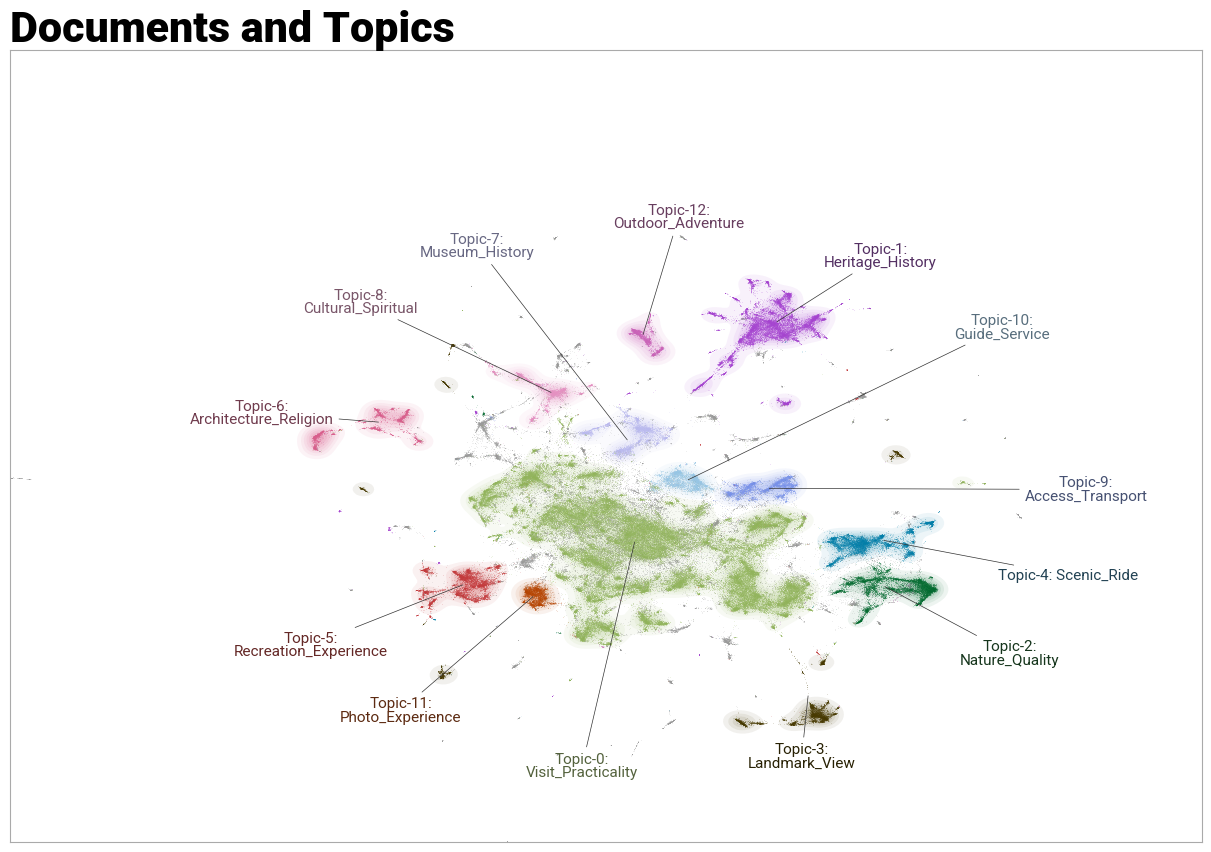

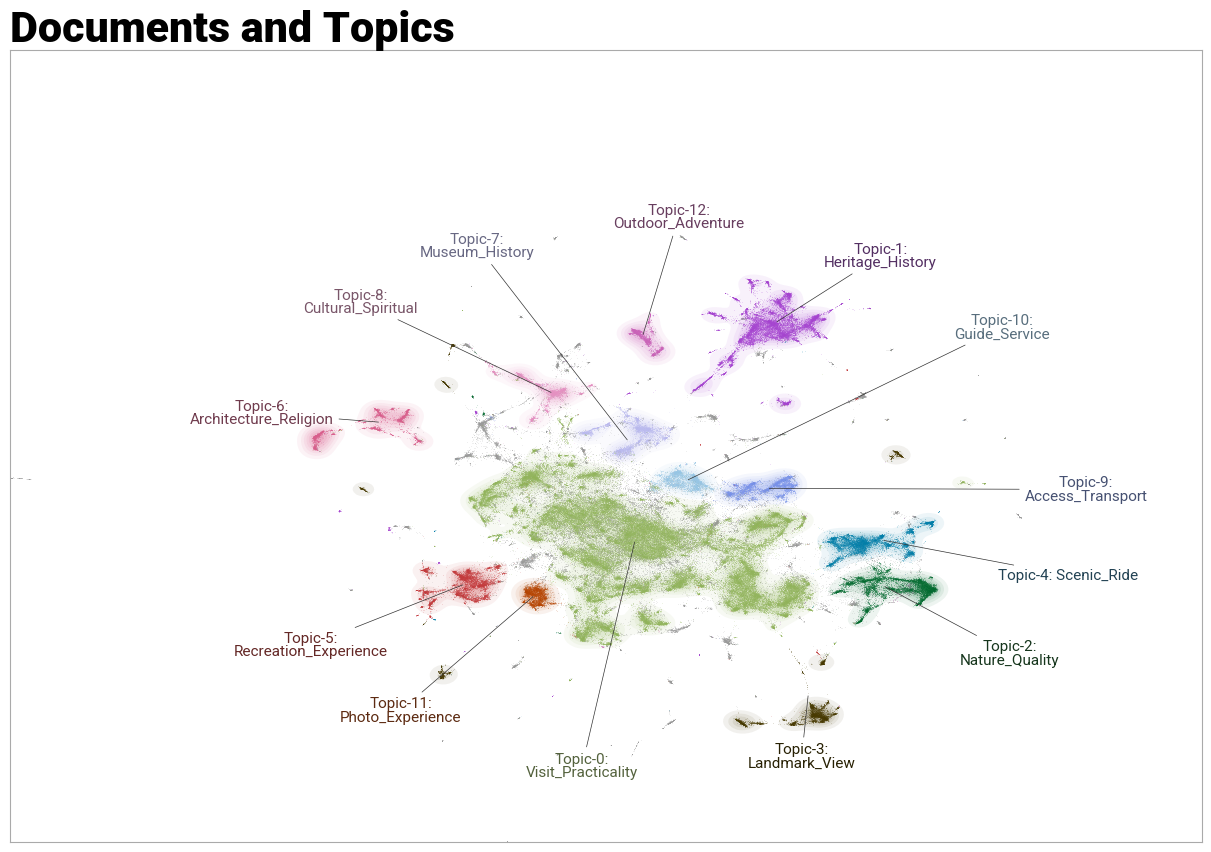

In [ ]:
fig = topic_model.visualize_document_datamap(
    docs=titles,
    topics=top_topics,
    reduced_embeddings=reduce_dimensions,
    width=1200,
    height=800,
    custom_labels=True,
    datamap_kwds=dict(
        label_font_size=11,
        label_wrap_width=20,
        use_medoids=True
    )
)

fig

In [ ]:
output_path = "/content/drive/MyDrive/CCDNCTKHDL/document_topic_map.png"

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

print("Đã lưu", output_path)

Đã lưu /content/drive/MyDrive/CCDNCTKHDL/document_topic_map.png
